In [1]:
import numpy as np
import mmcfilters
#import mmcfilters_notebook_compat as notebook_compat
#notebook_compat.install(mmcfilters)
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [2]:
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape

maxtree = mmcfilters.MorphologicalTree(imgInput, True, 1.5)
mintree = mmcfilters.MorphologicalTree(imgInput, False, 1.5)
tos4c8c = mmcfilters.MorphologicalTree(imgInput, interpolation=mmcfilters.ToSInterpolation.Min4cMax8c)
tos = mmcfilters.MorphologicalTree(imgInput, interpolation=mmcfilters.ToSInterpolation.SelfDual)


filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)
filterToS4c8c = mmcfilters.AttributeFilters(tos4c8c)
Type = mmcfilters.Attribute.Type

TypeError: mmcfilters.mmcfilters.MorphologicalTree: No constructor defined!

Text(0.5, 1.0, 'reconstruction (tos4c8c)')

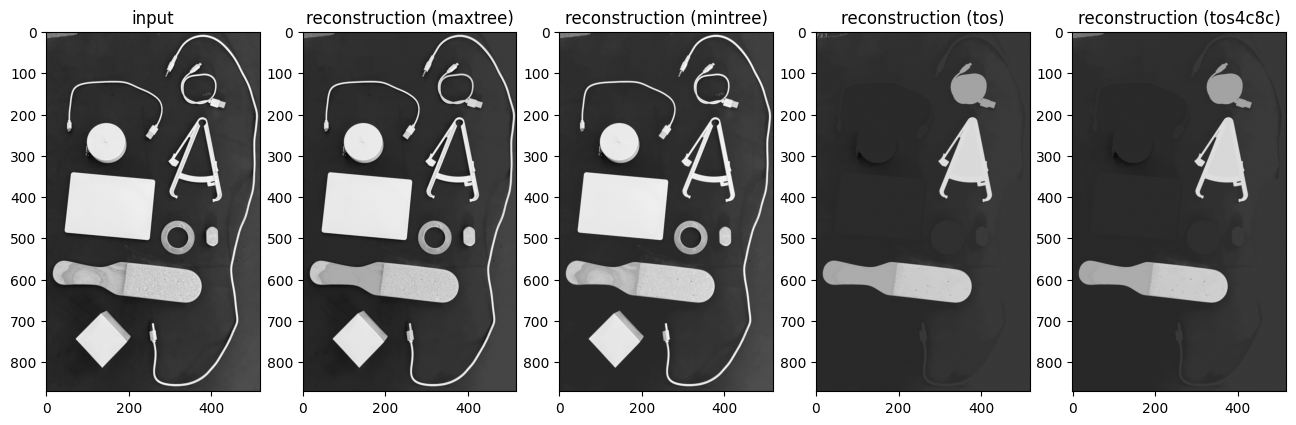

In [3]:
num_leafs = 20
attribute = Type.GRAY_HEIGHT

attr_maxtree = mmcfilters.Attribute.computeSingleAttribute(maxtree, attribute)
attr_mintree = mmcfilters.Attribute.computeSingleAttribute(mintree, attribute)
attr_tos = mmcfilters.Attribute.computeSingleAttribute(tos, attribute)
attr_tos4c8c = mmcfilters.Attribute.computeSingleAttribute(tos4c8c, attribute)



plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(filterMaxtree.filteringByExtinction(attr_maxtree, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(filterMintree.filteringByExtinction(attr_mintree, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (mintree)')

plt.subplot(1,5, 4)
plt.imshow(filterToS.filteringByExtinction(attr_tos, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos)')

plt.subplot(1,5, 5)
plt.imshow(filterToS4c8c.filteringByExtinction(attr_tos4c8c, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos4c8c)')

Text(0.5, 1.0, 'reconstruction (tos4c8c)')

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


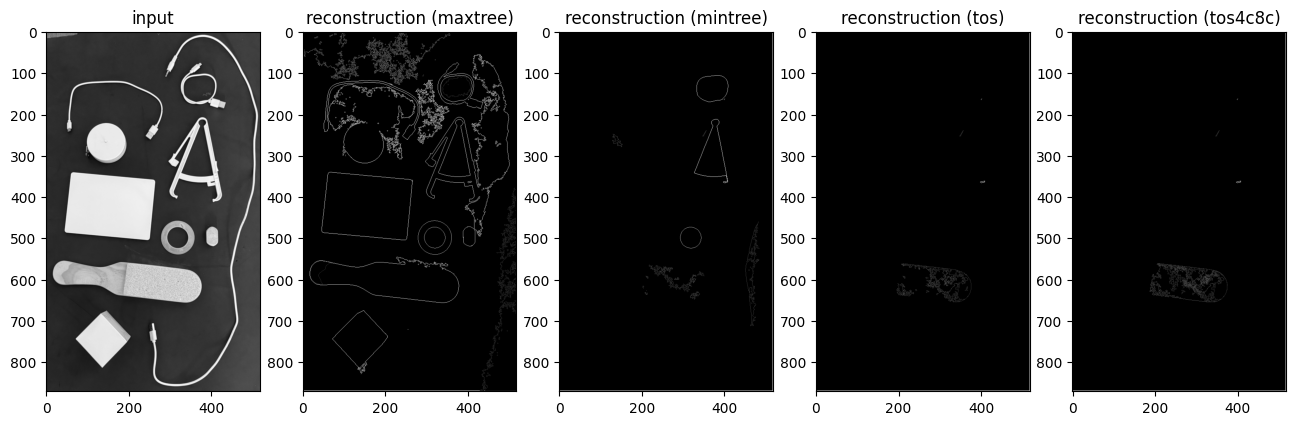

In [4]:
plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(filterMaxtree.saliencyMapByExtinction(attr_maxtree, num_leafs).reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(filterMintree.saliencyMapByExtinction(attr_mintree, num_leafs).reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (mintree)')

plt.subplot(1,5, 4)
plt.imshow(np.zeros_like(imgInput), cmap='gray', vmax=255, vmin=0)
plt.title('saliency unavailable (self-dual ToS)')
plt.axis('off')

plt.subplot(1,5, 5)
plt.imshow(np.zeros_like(imgInput), cmap='gray', vmax=255, vmin=0)
plt.title('saliency unavailable (ToS 4c8c)')
plt.axis('off')

Text(0.5, 1.0, 'attribute filter (tos4c8c)')

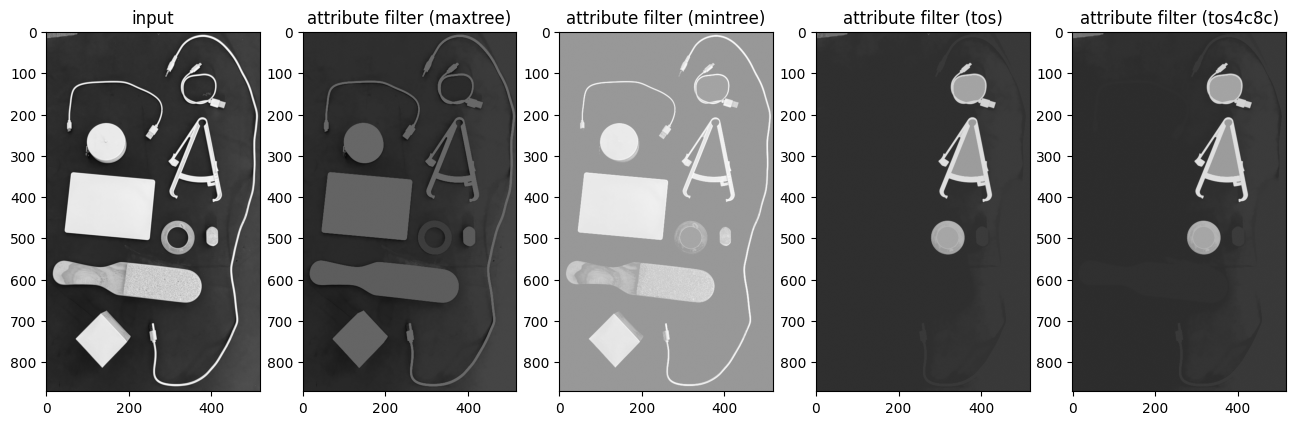

In [5]:
threshold = 150

imgFilteredMaxtree = filterMaxtree.filteringMax(attr_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringMax(attr_mintree > threshold)
imgFilteredToS = filterToS.filteringMax(attr_tos > threshold)
imgFilteredToS4c8c = filterToS4c8c.filteringMax(attr_tos4c8c > threshold)

plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(imgFilteredMaxtree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(imgFilteredMintree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,5, 4)
plt.imshow(imgFilteredToS, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

plt.subplot(1,5, 5)
plt.imshow(imgFilteredToS4c8c, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos4c8c)')